# 1. Economic data audit

What was fetched, against what the registry declared, and how much it has been
revised since. This is stage gate one: nothing downstream is worth reading until
every series fetches, caches, and reloads identically.

Run `forecast fetch-data` before this notebook. All computation lives in the
package; this notebook only displays.

In [1]:
from datetime import date

import pandas as pd

from economic_regime_forecasting import pipeline_gates
from economic_regime_forecasting.configuration.registry import load_registries
from economic_regime_forecasting.configuration.run_settings import DEFAULT_RUN_SETTINGS
from economic_regime_forecasting.data import audit, indicator_outcomes
from economic_regime_forecasting.data.cache import SeriesCache
from economic_regime_forecasting.data.panel import assemble_point_in_time_panel, load_final_series
from economic_regime_forecasting.features.observation_matrix import build_observation_matrix
from economic_regime_forecasting.reporting import figures

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

settings = DEFAULT_RUN_SETTINGS
registry, indicators = load_registries()
cache = SeriesCache(settings.cache.raw, settings.cache.vintage)
today = date.today()
print(f"{len(registry.series)} series, {len(indicators)} indicators, as of {today}")

9 series, 10 indicators, as of 2026-09-09


## Every series, measured rather than assumed

The registry declares a start date for each series. This table measures the
actual one and flags any disagreement, so a declared fact cannot quietly go stale.

In [2]:
series_audits = audit.audit_series(registry, cache)
audit_table = audit.audit_table(series_audits)
audit_table

,series,identifier,role,frequency,units,transform,declared_start,observed_start,observed_end,observations,missing,publication_lag_days,revised,start_matches_registry
0,industrial_production,INDPRO,growth,monthly,index 2017 = 100,year_over_year_log_change,1919-01-01,1919-01-01,2026-07-01,1291,0,47,True,True
1,nonfarm_payroll_employment,PAYEMS,growth,monthly,thousands of persons,year_over_year_log_change,1939-01-01,1939-01-01,2026-08-01,1052,0,36,True,True
2,consumer_price_index,CPIAUCSL,inflation,monthly,index 1982-1984 = 100,year_over_year_log_change,1947-01-01,1947-01-01,2026-07-01,955,1,44,True,True
3,core_consumer_price_index,CPILFESL,inflation,monthly,index 1982-1984 = 100,year_over_year_log_change,1957-01-01,1957-01-01,2026-07-01,835,1,44,True,True
4,three_month_treasury_bill_rate,TB3MS,rates,monthly,percent per year,level,1934-01-01,1934-01-01,2026-08-01,1112,0,32,False,True
5,federal_funds_rate,FEDFUNDS,rates,monthly,percent per year,level,1954-07-01,1954-07-01,2026-08-01,866,0,32,False,True
6,ten_year_treasury_yield,GS10,rates,monthly,percent per year,level,1953-04-01,1953-04-01,2026-08-01,881,0,32,False,True
7,unemployment_rate,UNRATE,labour,monthly,percent of labour force,level,1948-01-01,1948-01-01,2026-08-01,944,1,36,True,True
8,recession_indicator,USREC,outcome_only,monthly,binary flag,level,1854-12-01,1854-12-01,2026-08-01,2061,0,400,True,True


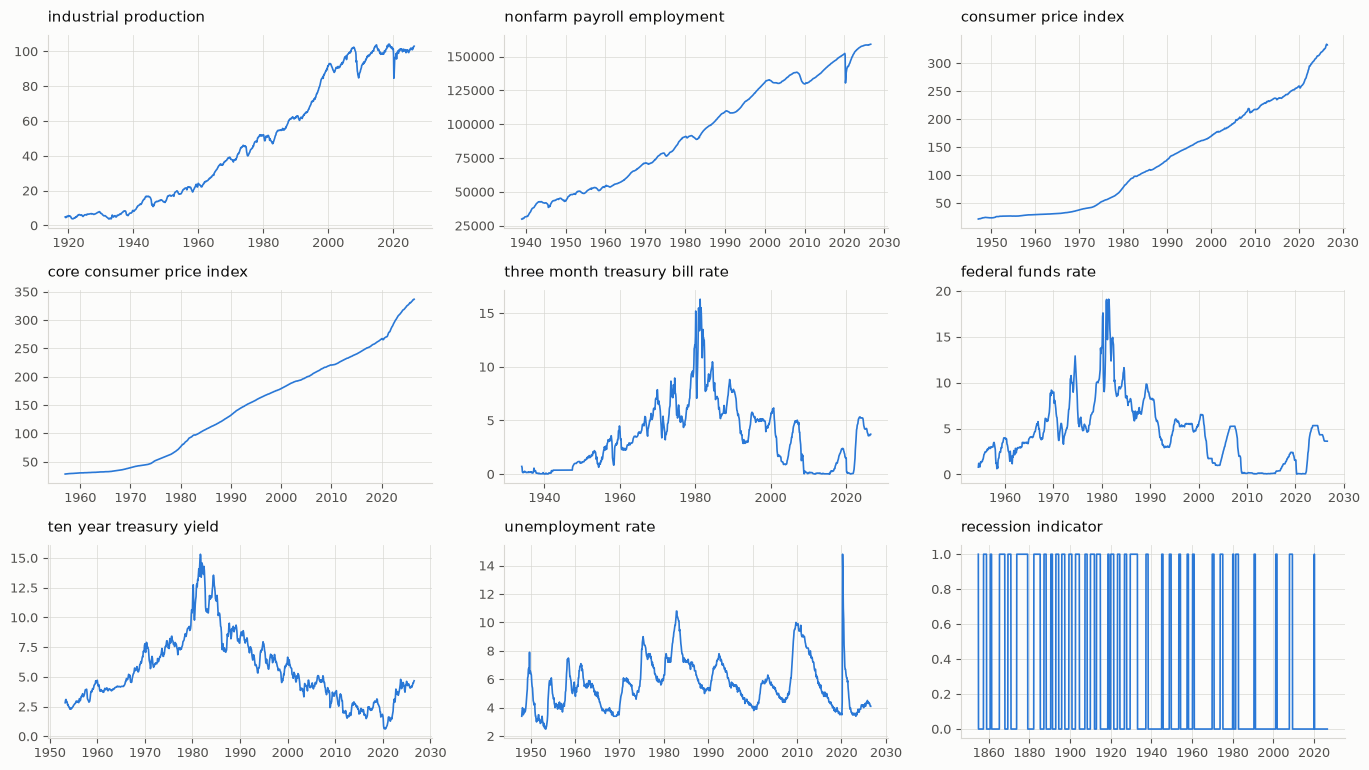

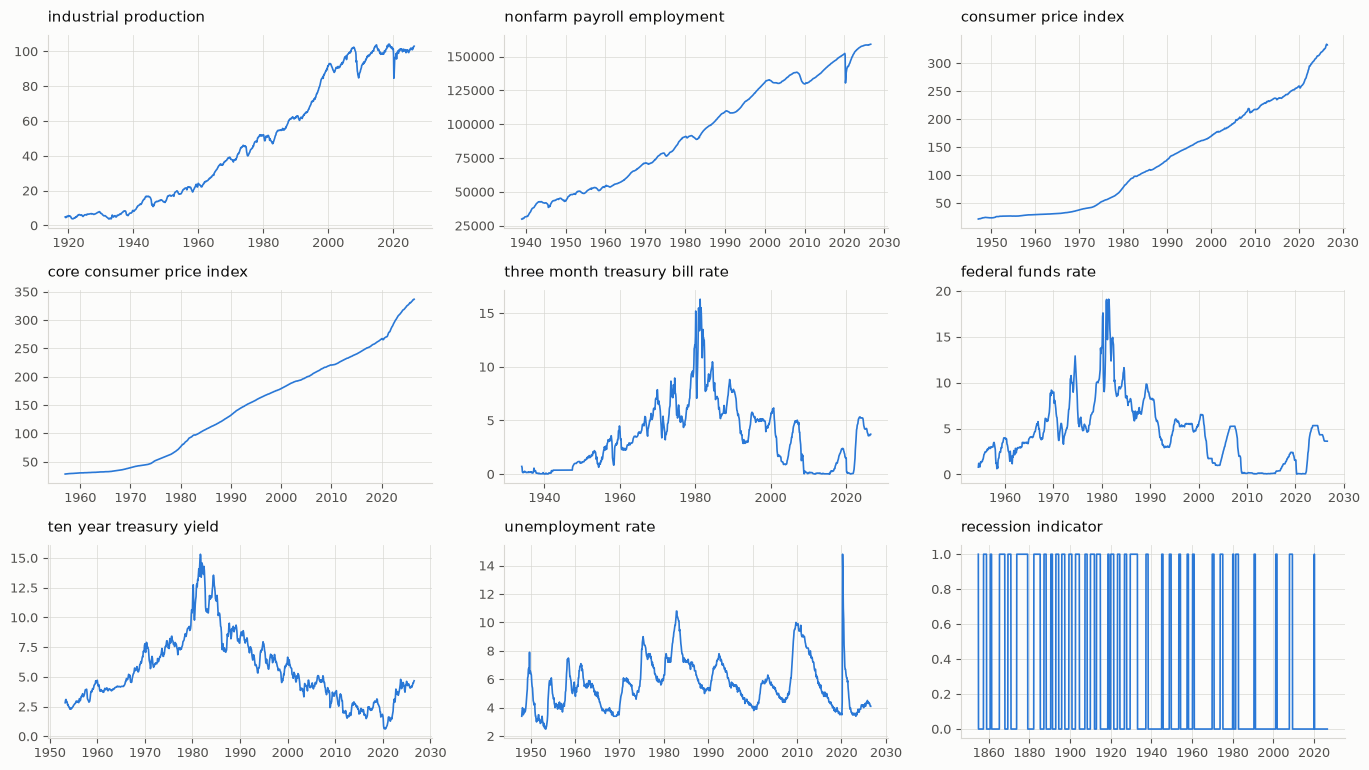

In [3]:
final_series = load_final_series(registry, cache, [item.name for item in registry.series])
figures.plot_series_panel(final_series)

## How much do these numbers move after publication?

The comparison is on year-over-year growth rather than the raw index, because the
index has been rebased repeatedly and a rebasing is not a revision. A 1970 vintage
puts January 1919 industrial production at 24.6 where a 2026 vintage puts it at
4.87; in growth terms those two vintages agree.

The `policy` column says which of the three point-in-time policies each vintage
date used. `publication_lag_fallback` means the archive had nothing usable that
far back, so the timing is right and the values are revised.

In [4]:
revisions = audit.audit_revisions(
    registry, cache, [date(year, 1, 1) for year in (1975, 1990, 2005, 2020)]
)
audit.revision_table(revisions)

vintage_fallback series=CPIAUCSL as_of=1975-01-01 archive_covers_from=1973-05-01 (19 months)
vintage_fallback series=CPIAUCSL as_of=1990-01-01 archive_covers_from=1988-05-01 (19 months)
vintage_fallback series=CPILFESL as_of=1975-01-01 archive_covers_from=nothing
vintage_fallback series=CPILFESL as_of=1990-01-01 archive_covers_from=nothing


,series,vintage,policy,months_compared,median_absolute_revision,largest_absolute_revision
0,industrial_production,1975-01-01,archival_vintage,659,0.001481,0.040954
1,industrial_production,1990-01-01,archival_vintage,839,0.001491,0.049299
2,industrial_production,2005-01-01,archival_vintage,995,0.000044,0.021846
3,industrial_production,2020-01-01,archival_vintage,1199,0.000015,0.018042
4,nonfarm_payroll_employment,1975-01-01,archival_vintage,419,0.000514,0.004865
5,nonfarm_payroll_employment,1990-01-01,archival_vintage,599,0.000468,0.004937
6,nonfarm_payroll_employment,2005-01-01,archival_vintage,779,0.000028,0.001694
7,nonfarm_payroll_employment,2020-01-01,archival_vintage,959,0.000000,0.003541
8,consumer_price_index,1975-01-01,publication_lag_fallback,323,0.000000,0.000000
9,consumer_price_index,1990-01-01,publication_lag_fallback,503,0.000000,0.000000


## The panel the model actually reads

Three standardised series, growth then inflation then rates. Its start is set by
the shortest input after a twelve-month growth window and a thirty-six month
standardisation window.

In [5]:
matrix = build_observation_matrix(assemble_point_in_time_panel(registry, today, cache), registry)
print(matrix.describe())
if matrix.bridged_months:
    print("interpolated across:", [f"{m:%Y-%m}" for m in matrix.bridged_months])
matrix.standardised.describe().round(3)

908 months from 1950-12 to 2026-07, as of 2026-09-09
interpolated across: ['2025-10']


,growth,inflation,rates
count,908.000,908.000,908.000
mean,-0.204,0.061,0.465
std,0.756,0.887,1.382
min,-3.884,-1.973,-2.026
25%,-0.533,-0.510,-0.678
50%,-0.126,-0.222,0.322
75%,0.260,0.381,1.513
max,2.229,3.148,4.598


## What the indicators resolve to

Each indicator's unconditional base rate over everything history has resolved.
These are the numbers the model has to beat.

In [6]:
outcome_series = load_final_series(
    registry, cache, indicator_outcomes.required_series_names(indicators)
)
resolved = indicator_outcomes.resolve_all(
    indicators, outcome_series, settings.forecast_horizons_in_months
)
pd.DataFrame(
    [
        {
            "indicator": name,
            "horizon_years": horizon // 12,
            "resolved": item.resolved_count,
            "positives": item.positive_count,
            "base_rate": round(item.base_rate, 3),
        }
        for (name, horizon), item in resolved.items()
    ]
).pivot(index="indicator", columns="horizon_years", values="base_rate")

horizon_years,1,5,10
indicator,,,
consumer_price_inflation_above_five_percent_within_horizon,0.299,0.537,0.746
consumer_price_inflation_above_three_percent_at_horizon,0.472,0.469,0.500
economy_in_recession_at_horizon_date,0.282,0.280,0.284
economy_in_recession_within_horizon,0.464,0.869,0.995
federal_funds_rate_above_four_percent_at_horizon,0.536,0.568,0.614
federal_funds_rate_below_one_percent_within_horizon,0.214,0.398,0.430
industrial_production_growth_above_two_percent_at_horizon,0.592,0.591,0.590
treasury_yield_curve_inverted_within_horizon,0.234,0.558,0.770
unemployment_rate_above_five_percent_at_horizon,0.608,0.624,0.655


## Gate 1

In [7]:
reload_cache = SeriesCache(settings.cache.raw, settings.cache.vintage)
audit.audit_series(registry, reload_cache)
print(pipeline_gates.gate_one_data(registry, series_audits, reload_cache.statistics).describe())

Gate 1 — data: PASS
  ok    every series in the registry was fetched and audited
        9 of 9 audited
  ok    each series starts where the registry says it does
        every declared start date matches the service
  ok    a second pass over the same series is served entirely from cache
        9 hit(s), 0 miss(es), 0 write(s); hit rate 100%
  ok    every series has at least twenty years of monthly history
        shortest is core_consumer_price_index with 835 observations
